In [3]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

In [4]:
# SSL / proxy setup for corporate network + quiet health check
import os
from pathlib import Path
import requests
from dotenv import load_dotenv

load_dotenv()

candidate_paths = [
    os.getenv("CORP_CA_BUNDLE"),
    os.getenv("REQUESTS_CA_BUNDLE"),
    os.getenv("SSL_CERT_FILE"),
    "/etc/ssl/certs/ca-certificates.crt",
    "/usr/lib/ssl/cert.pem",
]

selected_bundle = next(
    (path for path in candidate_paths if path and Path(path).exists()),
    None,
 )

if selected_bundle:
    os.environ["REQUESTS_CA_BUNDLE"] = selected_bundle
    os.environ["SSL_CERT_FILE"] = selected_bundle

diagnostics = []

if not selected_bundle:
    diagnostics.append(
        "No CA bundle found from known paths. Set CORP_CA_BUNDLE in .env."
    )

if not os.getenv("http_proxy") and not os.getenv("https_proxy"):
    diagnostics.append(
        "No proxy env detected. If required in your network, set http_proxy/https_proxy in .env."
    )

try:
    requests.get("https://api.tavily.com", timeout=10)
except requests.exceptions.SSLError as exc:
    diagnostics.append(
        "TLS handshake failed. Export corporate root cert to PEM and set CORP_CA_BUNDLE in .env."
    )
    diagnostics.append(f"SSL error: {exc}")
except Exception as exc:
    diagnostics.append(
        f"Connectivity check failed with {type(exc).__name__}: {exc}"
    )

if diagnostics:
    print("[SSL Check] Action needed:")
    for line in diagnostics:
        print(f"- {line}")

# Research Agent 

*The goal of research is to gather the context requested by the research brief.*

Here is our overall research flow:

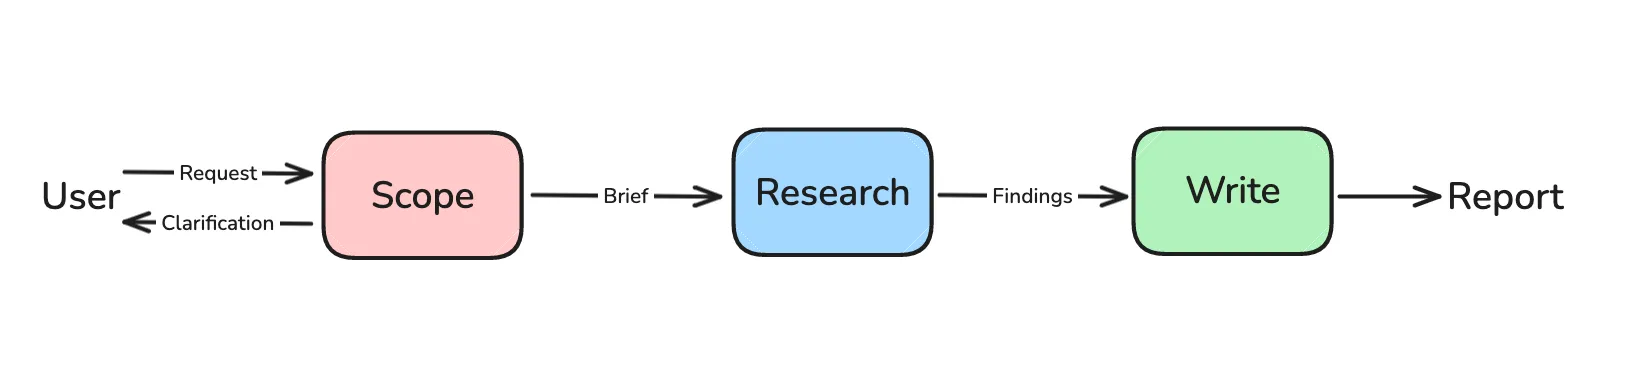

Research is an open‑ended task. The best strategy to answer a user request can't be easily known in advance. 

Requests can require different research strategies and varying levels of search depth. Consider this request:

> *"Compare these two products"*

Comparisons typically benefit from search on each product, followed by a synthesis step to compare them. Now, consider this one:

> *"Give me the top candidates for my job posting"*

Listing and ranking requests typically require open-ended search, followed by a synthesis and ranking.
 
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) are well suited to research because they can flexibly apply different strategies, using intermediate results to guide their exploration.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

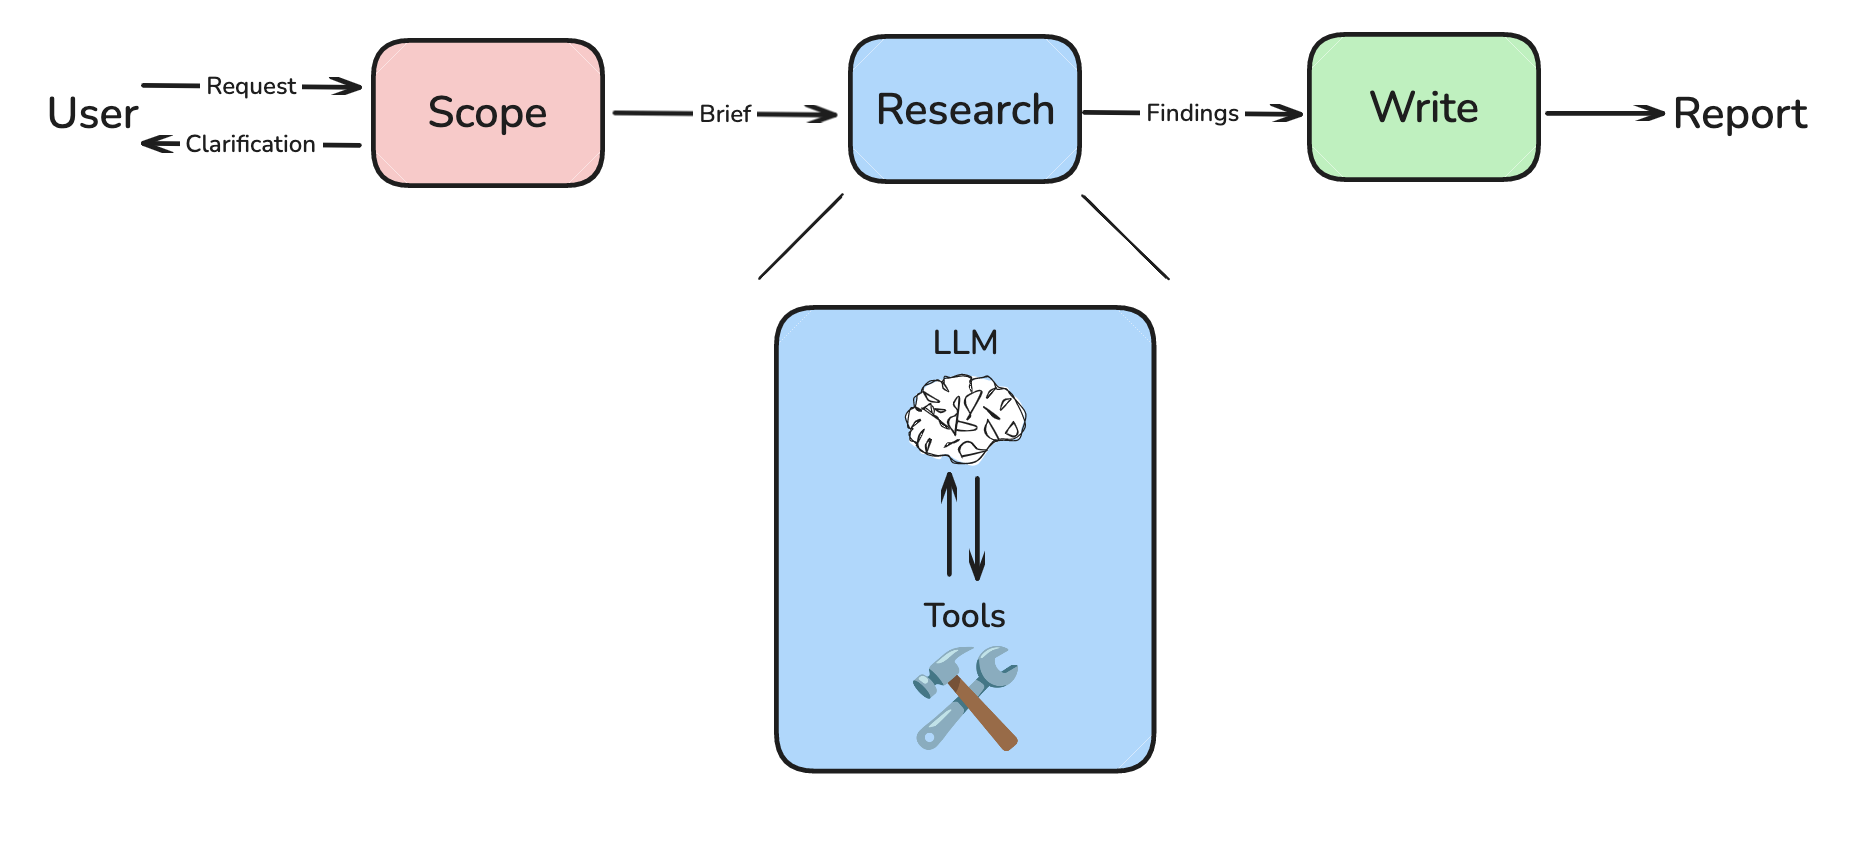

### Prompt

First, we'll define a prompt that instructs our agent to use available search tools. 

To prevent excessive tool calls and maintain research focus, we use [a few prompting techniques for agents](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

#### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Start with broader searches** - Use broad, comprehensive queries first
- **After each search, pause and assess** - Do I have enough to answer? What's still missing?
- **Execute narrower searches as you gather information** - Fill in the gaps.

#### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Stop when you can answer confidently** - Don't keep searching for perfection.
- **Give it budgets** - Use 2-3 search tool calls for simple queries. Use up to 5 for complex queries.
- **Limit** - Always stop after 5 search tool calls if you cannot find the right source(s).

#### 3. Show your thinking
After each search tool calling, use [`think_tool` to analyze the results](https://www.anthropic.com/engineering/claude-think-tool):
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

#### Results
These techniques transform problematic research behavior like:
```
"best coffee shops SF" → "Saint Frank Coffee details" → "Sightglass Coffee details" → "Ritual Coffee details" → etc. (20+ searches)
```

Into efficient patterns like:
```
"best coffee shops SF" → ThinkTool(analyze results) → "SF specialty coffee quality ratings" → ThinkTool(assess completeness) → provide answer (3-5 searches total)
```

The key insight: **Think like a human researcher with limited time** - this prevents the "spin-out problem" where agents continue searching indefinitely.

In [5]:
from utils import show_prompt
from deep_research_from_scratch.prompts import research_agent_prompt
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Image Collection>                                                                                             │
│  Search results may include relevant images (charts, diagrams, screenshots, data visualizations).               │
│  Note any images that are directly relevant to the research topic in your thinking — these will be              │
│  preserved and embedded in the final report. You do not need to take any special action to collect              │
│  images; they are captured automatically from search results.                                                   │
│  </Image Collection>                                                                                            │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                      

### State and Schemas

We'll create the agent state object.


In [6]:
%%writefile ../src/deep_research_from_scratch/state_research.py

"""State Definitions and Pydantic Schemas for Research Agent.

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from typing_extensions import Annotated, List, Sequence, TypedDict

# ===== IMAGE METADATA SCHEMA =====

class ImageResult(BaseModel):
    """Schema for image metadata collected during research."""

    url: str = Field(description="URL of the image")
    title: str = Field(
        description="Title or alt text of the image", default=""
    )
    source_page: str = Field(
        description="URL of the page where the image was found", default=""
    )
    description: str = Field(
        description="Brief description of the image content", default=""
    )
    local_path: str | None = Field(
        description="Local file path after download", default=None
    )

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """State for the research agent containing message history and research metadata.

    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    images: Annotated[List[ImageResult], operator.add]

class ResearcherOutputState(TypedDict):
    """Output state for the research agent containing final research results.

    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    images: Annotated[List[ImageResult], operator.add]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")


Overwriting ../src/deep_research_from_scratch/state_research.py


Now, we'll define our research tool.  

#### Tavily SDK Integration

We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance

#### Alternative Web Content Sources

While we use Tavily's search API in this tutorial, there are several other excellent options for web content extraction:

- **[Tavily Extract](https://docs.tavily.com/documentation/api-reference/endpoint/extract)**: Tavily's dedicated content extraction endpoint that can extract and clean content from specific URLs without performing searches
- **[Jina Reader](https://jina.ai/reader/)**: A powerful web content extraction service that converts web pages to clean, LLM-friendly text by simply prepending `https://r.jina.ai/` to any URL
- **[Firecrawl](https://www.firecrawl.dev/)**: A comprehensive web scraping platform that converts websites into clean markdown or structured data, with advanced features like JavaScript rendering and sitemap crawling

Each tool has different strengths: Tavily excels at search-first workflows, Jina Reader offers the simplest URL-to-text conversion, and Firecrawl provides the most comprehensive web scraping capabilities for complex sites.

####  LangChain Tools

We'll convert our Tavily search function into a [LangChain tool](https://python.langchain.com/docs/concepts/tools/) using the `@tool` decorator. This enables:
- Automatic schema generation for the LLM
- Integration with LangChain's agent framework
- Standardized tool calling interface
- Type validation and documentation

Note that some of the arguments are noted as [InjectedToolArg](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.base.InjectedToolArg.html). These are not included in the tool schema sent to the LLM, and instead are injected during execution. This gives us the flexibility to inject values at runtime, but does not burden the language model with the responsibility of managing these arguments.

In [7]:
%%writefile ../src/deep_research_from_scratch/utils.py

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

import contextvars
import json
import logging
import os
from datetime import datetime
from functools import wraps
from pathlib import Path
from urllib.parse import urlparse

import requests
import urllib3
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import InjectedToolArg, tool
from tavily import TavilyClient
from typing_extensions import Annotated, List, Literal

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.prompts import summarize_webpage_prompt
from deep_research_from_scratch.state_research import ImageResult, Summary

load_dotenv()
logger = logging.getLogger(__name__)

# ===== SSL CONFIGURATION =====
# Set DISABLE_SSL_VERIFY=true in .env to skip certificate verification when
# operating behind a corporate proxy with self-signed certificates.
_DISABLE_SSL = os.getenv("DISABLE_SSL_VERIFY", "").lower() in ("1", "true", "yes")
if _DISABLE_SSL:
    import ssl

    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    # --- Layer 1: patch Python's ssl module ---
    ssl._create_default_https_context = ssl._create_unverified_context  # noqa: SLF001

    # --- Layer 2: patch urllib3 at the connection-pool level ---
    # This is the most reliable hook because %autoreload in Jupyter
    # can reload `requests` / `requests.sessions` (resetting any
    # monkey-patches on Session.request or requests.post) but it does
    # NOT reload urllib3's compiled connection pool classes.
    _orig_urlopen = urllib3.HTTPSConnectionPool.urlopen

    @wraps(_orig_urlopen)
    def _unverified_urlopen(self, *args, **kwargs):  # noqa: ANN001
        # Force no cert verification at the urllib3 level
        self.cert_reqs = "CERT_NONE"
        self.assert_hostname = False
        return _orig_urlopen(self, *args, **kwargs)

    urllib3.HTTPSConnectionPool.urlopen = _unverified_urlopen

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

_DEFAULT_SUMMARIZATION_MODEL = "azure_openai:gpt-4.1"
_runtime_config: contextvars.ContextVar[dict] = contextvars.ContextVar(
    "runtime_config",
    default={},
)


def set_runtime_config(configurable: dict | None) -> None:
    """Store runtime model overrides for tool-side model resolution."""
    _runtime_config.set(dict(configurable or {}))


def get_runtime_config() -> dict:
    """Return the current runtime model overrides for tool-side helpers."""
    return dict(_runtime_config.get())


_last_search_images: contextvars.ContextVar[list[ImageResult]] = (
    contextvars.ContextVar("last_search_images", default=[])
)


def get_last_search_images() -> list[ImageResult]:
    """Retrieve images extracted from the most recent search call.

    Used by tool_node to pass image metadata into the agent state
    without changing the tool's string return interface.
    """
    return list(_last_search_images.get())


def normalize_model_id(model_id: str) -> str:
    """Normalize Azure model identifiers to use the expected deployment casing."""
    provider, separator, deployment = model_id.partition(":")
    if not separator:
        return model_id
    return f"{provider}{separator}{deployment.upper()}"


def _build_summarization_model(
    model_id: str | None = None,
    temperature: float = 0.0,
):
    """Build the summarization model with a fresh GenAI token.

    Fallback order is:
    1. Explicit ``model_id`` argument
    2. Runtime ``summarization_model`` override
    3. Runtime ``research_model`` override
    4. Default summarization model
    """
    runtime_config = get_runtime_config()
    resolved_model_id = (
        model_id
        or runtime_config.get("summarization_model")
        or runtime_config.get("research_model")
        or _DEFAULT_SUMMARIZATION_MODEL
    )
    normalized_model_id = normalize_model_id(resolved_model_id)
    deployment = normalized_model_id.split(":")[-1]
    return init_chat_model(
        model=normalized_model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        temperature=temperature,
    )


tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str],
    max_results: int = 3,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = True,
    include_images: bool = True,
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content
        include_images: Whether to include image URLs in results

    Returns:
        List of search result dictionaries
    """
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic,
            include_images=include_images,
        )
        search_docs.append(result)

    return search_docs


def extract_images_from_search_results(
    search_results: List[dict],
) -> list[ImageResult]:
    """Extract deduplicated image metadata from Tavily search responses.

    Handles both plain URL strings and dict-format image entries
    (when Tavily returns descriptions). Populates ``title`` from dict
    entries when available; ``source_page`` is left empty because the
    Tavily API does not attribute images to specific result pages.

    Args:
        search_results: List of raw Tavily search response dicts

    Returns:
        Deduplicated list of ImageResult objects
    """
    seen_urls: set[str] = set()
    images: list[ImageResult] = []

    for response in search_results:
        for img in response.get("images", []):
            if isinstance(img, str):
                url, description, title = img, "", ""
            elif isinstance(img, dict):
                url = img.get("url", "")
                description = img.get("description", "")
                title = img.get("title", "")
            else:
                continue

            if url and url not in seen_urls:
                seen_urls.add(url)
                images.append(
                    ImageResult(
                        url=url,
                        description=description,
                        title=title,
                    )
                )

    return images

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.

    Args:
        webpage_content: Raw webpage content to summarize

    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Rebuild the model for each call so expired GenAI tokens are refreshed.
        structured_model = _build_summarization_model().with_structured_output(Summary)

        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content,
                date=get_today_str()
            ))
        ])

        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )

        return formatted_summary

    except Exception as e:
        logger.warning("Failed to summarize webpage: %s", e)
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.

    Args:
        search_results: List of search result dictionaries

    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}

    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result

    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.

    Args:
        unique_results: Dictionary of unique search results

    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}

    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])

        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }

    return summarized_results

def format_search_output(
    summarized_results: dict,
    images: list[ImageResult] | None = None,
) -> str:
    """Format search results into a well-structured string output.

    Args:
        summarized_results: Dictionary of processed results
        images: Optional list of image metadata to append

    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."

    formatted_output = "Search results: \n\n"

    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"

    if images:
        formatted_output += "\n\n--- IMAGES FOUND ---\n"
        for i, img in enumerate(images, 1):
            formatted_output += f"\n[Image {i}]: {img.url}"
            if img.description:
                formatted_output += f"\n  Description: {img.description}"
            formatted_output += "\n"

    return formatted_output

# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
        include_images=True,
    )

    # Extract image metadata and store for retrieval by tool_node
    images = extract_images_from_search_results(search_results)
    _last_search_images.set(images)

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption (includes images section)
    return format_search_output(summarized_results, images=images)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"


# ===== IMAGE DOWNLOAD =====

def download_images(
    images: list[ImageResult],
    output_dir: str | Path,
    timeout: int = 5,
) -> list[ImageResult]:
    """Download images to local disk with best-effort error handling.

    Each image is downloaded individually with a timeout. Failures are
    logged but do not prevent other images from being downloaded.
    A metadata JSON file is written alongside the downloaded images.

    Args:
        images: List of ImageResult objects to download
        output_dir: Directory to save downloaded images
        timeout: Per-image download timeout in seconds

    Returns:
        Updated list of ImageResult objects with local_path populated
        for successfully downloaded images
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    verify_ssl = os.getenv("DISABLE_SSL_VERIFY", "").lower() not in (
        "1", "true", "yes",
    )

    _VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".webp", ".svg"}
    _CONTENT_TYPE_MAP = {
        "png": ".png",
        "gif": ".gif",
        "webp": ".webp",
        "svg": ".svg",
        "jpeg": ".jpg",
        "jpg": ".jpg",
    }

    updated: list[ImageResult] = []

    for idx, img in enumerate(images):
        try:
            resp = requests.get(img.url, timeout=timeout, verify=verify_ssl)
            resp.raise_for_status()

            # Derive filename from URL path
            parsed = urlparse(img.url)
            filename = Path(parsed.path).name or ""
            suffix = Path(filename).suffix.lower() if filename else ""

            if suffix not in _VALID_EXTENSIONS:
                # Infer extension from Content-Type header
                content_type = resp.headers.get("content-type", "")
                ext = None
                for key, val in _CONTENT_TYPE_MAP.items():
                    if key in content_type:
                        ext = val
                        break
                if ext is None:
                    logger.warning(
                        "Skipping image with unsupported format: %s "
                        "(content-type: %s)",
                        img.url,
                        content_type,
                    )
                    updated.append(img)
                    continue
                filename = f"image_{idx:03d}{ext}"
            else:
                # Prefix index to avoid filename collisions across domains
                stem = Path(filename).stem
                filename = f"{idx:03d}_{stem}{suffix}"

            filepath = output_path / filename
            filepath.write_bytes(resp.content)
            updated.append(img.model_copy(update={"local_path": str(filepath)}))
            logger.info("Downloaded image: %s -> %s", img.url, filepath)

        except Exception as e:
            logger.warning("Failed to download image %s: %s", img.url, e)
            updated.append(img)  # keep original without local_path

    # Persist structured metadata alongside downloaded images
    metadata_path = output_path / "images_metadata.json"
    metadata = [i.model_dump() for i in updated]
    metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False))

    return updated


Overwriting ../src/deep_research_from_scratch/utils.py


### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [8]:
%%writefile ../src/deep_research_from_scratch/research_agent.py

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

import os

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    ToolMessage,
    filter_messages,
)
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, StateGraph
from typing_extensions import Literal

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.prompts import (
    compress_research_human_message,
    compress_research_system_prompt,
    research_agent_prompt,
)
from deep_research_from_scratch.state_research import (
    ResearcherOutputState,
    ResearcherState,
)
from deep_research_from_scratch.utils import (
    get_last_search_images,
    get_today_str,
    normalize_model_id,
    set_runtime_config,
    tavily_search,
    think_tool,
)

load_dotenv()

# ===== CONFIGURATION =====

# Model role defaults
_DEFAULT_RESEARCH_MODEL = "azure_openai:GPT-54-2026-03-05"
_DEFAULT_SUMMARIZATION_MODEL = "azure_openai:GPT-54-2026-03-05"  # used by tool-side webpage summarization when configured
_DEFAULT_COMPRESS_MODEL = "azure_openai:GPT-54-2026-03-05"

# Tools are module-level (no model dependency)
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}


def _build_model(model_id: str, **kwargs):
    """Build an Azure OpenAI model instance from a model identifier string.

    Extracts the deployment name from the model identifier using the
    convention that model name equals deployment name (e.g.,
    "azure_openai:gpt-54-2026-03-05" -> deployment "GPT-54-2026-03-05").
    """
    normalized_model_id = normalize_model_id(model_id)
    deployment = normalized_model_id.split(":")[-1]
    return init_chat_model(
        model=normalized_model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        **kwargs,
    )


# ===== AGENT NODES =====

def llm_call(state: ResearcherState, config: RunnableConfig):
    """Analyze current state and decide on next actions.

    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information

    Model is controlled by config["configurable"]["research_model"]
    (default: "azure_openai:gpt-4.1").

    Returns updated state with the model's response.
    """
    configurable = config.get("configurable", {})
    set_runtime_config(configurable)
    model = _build_model(
        configurable.get("research_model", _DEFAULT_RESEARCH_MODEL),
        temperature=0.0,
    )
    model_with_tools = model.bind_tools(tools)

    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }


def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.

    Executes all tool calls from the previous LLM responses.
    After each tavily_search call, captures image metadata via
    contextvars and deduplicates against already-collected images.
    Returns updated state with tool execution results and new images.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls

    observations = []
    new_images = []
    seen_urls = {img.url for img in state.get("images", [])}

    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
        if tool_call["name"] == "tavily_search":
            for img in get_last_search_images():
                if img.url not in seen_urls:
                    seen_urls.add(img.url)
                    new_images.append(img)

    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]

    return {"researcher_messages": tool_outputs, "images": new_images}


def compress_research(state: ResearcherState, config: RunnableConfig) -> dict:
    """Compress research findings into a concise summary.

    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.

    Model is controlled by config["configurable"]["compress_model"]
    (default: "azure_openai:gpt-4.1").
    """
    configurable = config.get("configurable", {})
    set_runtime_config(configurable)
    compress_model = _build_model(
        configurable.get("compress_model", _DEFAULT_COMPRESS_MODEL),
        temperature=0.0,
        max_tokens=16384,
    )

    system_message = compress_research_system_prompt.format(date=get_today_str())

    # Append structured image metadata so references survive compression
    human_content = compress_research_human_message
    images = state.get("images", [])
    if images:
        image_lines = [
            f"- {img.url}"
            + (f" — {img.description}" if img.description else "")
            for img in images
        ]
        human_content += (
            "\n\n--- IMAGES COLLECTED DURING RESEARCH ---\n"
            + "\n".join(image_lines)
            + "\nPreserve references to relevant images in your "
            "compressed output."
        )

    messages = (
        [SystemMessage(content=system_message)]
        + state.get("researcher_messages", [])
        + [HumanMessage(content=human_content)]
    )
    response = compress_model.invoke(messages)

    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"],
            include_types=["tool", "ai"]
        )
    ]

    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }


# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.

    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.

    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tool_node"
    return "compress_research"


# ===== GRAPH CONSTRUCTION =====

agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node",
        "compress_research": "compress_research",
    },
)
agent_builder.add_edge("tool_node", "llm_call")
agent_builder.add_edge("compress_research", END)

researcher_agent = agent_builder.compile()


Overwriting ../src/deep_research_from_scratch/research_agent.py


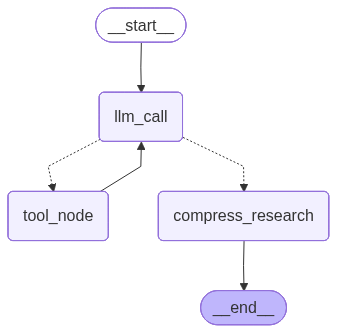

In [9]:
import base64
import httpx
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# Show the agent
mermaid = researcher_agent.get_graph(xray=True).draw_mermaid()
encoded = base64.urlsafe_b64encode(mermaid.encode("utf-8")).decode("ascii")
image_url = f"https://mermaid.ink/img/{encoded}?type=png&bgColor=%21white"

with httpx.Client(timeout=20.0, verify=False, trust_env=True) as client:
    response = client.get(image_url)
    response.raise_for_status()
    png_bytes = response.content

display(Image(png_bytes))

In [10]:
# Run the agent
import uuid

from utils import format_messages, init_langfuse_tracing
from langchain_core.messages import HumanMessage

langfuse_handler = init_langfuse_tracing()

# Example brief
research_brief = """请研究近半年来（以今天 Fri Apr 24, 2026 为基准，约过去 6                                                           
个月）中国市场高端面部精华与面霜中“内容物本身”的液体/膏体设计元素趋势，明确排除外包装、瓶器、盒身、标签、泵头等包装
设计因素。我希望重点分析产品内容物在视觉与感官层面的趋势，包括：颜色（如透明、半透明、乳白、珠光、金属感、渐变感等 
）、装饰（如金箔/银箔、胶囊珠、悬浮颗粒、微气泡、花瓣/植物碎片、闪片等可见添加物或视觉点缀）、纹理感（如水感、凝胶 
感、丝绒感、奶霜感、啫喱感、拉丝感、厚薄度、流动性、包裹感等）。请优先使用中文来源，并尽量链接到品牌官方页面、品牌 
官方社媒/视频号/小红书/天猫旗舰店/京东旗舰店、权威美妆零售平台、行业媒体或可直接看到产品内容物实拍/演示的原始来源，
而不是二手汇总博客。请在研究中附上可参考图片或可直接查看图片/视频的原始链接，图片应尽量展示内容物本身而非包装。    

请按以下维度拆解趋势研究：                                                                                         

 1 [Geographic Market]                                                                                             
   在中国市场，近半年来高端面部精华/面霜内容物设计出现了哪些主流与新兴趋势？请限定在中国消费者可购买、且在中国市场 
   有传播与上新动作的高端品牌/产品，必要时区分国际品牌在中国与本土高端品牌的表现差异。                             
 2 [Product Category + Product Format]                                                                             
   面部精华与面霜这两个子品类中，内容物设计元素分别呈现出哪些不同趋势？请区分精华、乳霜，以及必要时纳入相关近邻质地
   （如精华凝胶、乳液霜、睡眠面膜式面霜）作为开放考虑，但不要偏离“面部精华/面霜”主范围。                           
 3 [Aesthetic Direction + Sensory Experience]                                                                      
   从颜色、装饰、纹理感三个核心维度出发，当前高端产品内容物的审美方向与感官体验趋势是什么？请总结高频视觉代码、触感
   联想、仪式感表达，以及这些设计如何服务于“高端感”“功效感”或“愉悦感”的传达。                                      
 4 [Claims and Evidence + Ingredient Strategy]                                                                     
   这些内容物设计元素通常如何与功效诉求、成分故事或科技话术绑定？请分析例如修护、抗老、焕亮、舒缓、屏障、奢养等常见
   高端护肤诉求，如何通过颜色、可见颗粒、珠光、胶囊化、悬浮体系、特殊纹理等被视觉化表达；若某些设计更多是审美/营销 
   导向而非功效必要，也请明确指出。                                                                                
 5 [Channel and Touchpoint + Trend Momentum]                                                                       
   哪些渠道最能观察到这些趋势的形成与扩散（如品牌官方图、上脸演示视频、达人测评、小红书、抖音、天猫详情页、专柜展示
   等）？请判断各类内容物设计趋势在近半年来是“新兴信号、加速增长、已趋主流还是热度回落”，并尽量给出可支持判断的上新
   案例、传播热度或重复出现信号。                                                                                  
 6 [Business Impact + Value Positioning]                                                                           
   从高端定位角度看，这些内容物设计趋势对品牌的商业与产品策略意味着什么？请分析哪些液体/膏体设计元素更常见于高端价 
   位带，哪些可能成为同质化风险，哪些可能构成未来的差异化机会。若价格带边界未被用户明确定义，请将“高端”作为中国护肤
   市场中的 premium/luxury 语境处理，并在研究中说明所采用的判断标准。                                              

输出时请尽量给出：代表性趋势清单、每个趋势对应的具体品牌/产品案例、可查看内容物的图片或视频链接、以及简要说明该案例
为何能代表该趋势。若某些图片仅能通过电商详情页、官方社媒帖子或视频截图观察，请明确标注来源与可见内容物的程度。
"""

thread_id = str(uuid.uuid4())
trace_tag = f"nb2-research-{thread_id[:8]}"
thread = {"configurable": {"thread_id": thread_id, "recursion_limit": "50", 
                           "scope_model":         "azure_openai:GPT-54-2026-03-05",
                            "research_model":      "azure_openai:GPT-54-2026-03-05",
                            "summarization_model": "azure_openai:GPT-54-2026-03-05",
                            "compress_model":      "azure_openai:GPT-54-2026-03-05",
                            "supervisor_model":    "azure_openai:GPT-54-2026-03-05",
                            "writer_model":        "azure_openai:GPT-54-2026-03-05",
         },
         "callbacks": [langfuse_handler],
         "tags": [trace_tag],
         "metadata": {
             "thread_id": thread_id,
             "notebook": "2_research_agent",
             "langfuse_session_id": thread_id,
             "langfuse_tags": [trace_tag],
         },
}
result = researcher_agent.invoke(
    {
        "researcher_messages": [HumanMessage(content=f"{research_brief}.")],
        "tool_call_iterations": 0,
        "research_topic": research_brief,
        "compressed_research": "",
        "raw_notes": [],
        "images": [],
    },
    config=thread
)
format_messages(result['researcher_messages'])

Failed to summarize webpage: Error code: 422 - {'detail': [{'type': 'enum', 'loc': ['path', 'deployment_id'], 'msg': "Input should be 'GPT-5-2025-08-07', 'GPT-5-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-MINI-2025-08-07', 'GPT-5-MINI-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-MINI-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-NANO-2025-08-07', 'GPT-5-NANO-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-NANO-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-CHAT-2025-08-07', 'GPT-51-2025-11-13', 'GPT-51-2025-11-13-LOW-CONTENT-FILTERS', 'GPT-51-2025-11-13-NO-CONTENT-FILTERS', 'GPT-52-2025-12-11', 'GPT-52-2025-12-11-LOW-CONTENT-FILTERS', 'GPT-52-2025-12-11-NO-CONTENT-FILTERS', 'GPT-53-CHAT-2026-03-03', 'GPT-53-CHAT-2026-03-03-LOW-CONTENT-FILTERS', 'GPT-53-CHAT-2026-03-03-NO-CONTENT-FILTERS', 'GPT-54-2026-03-05', 'GPT-54-2026-03-05-LOW-CONTENT-FILTERS', 'GPT-54-2026-03-05-NO-CONTENT-FILTERS', 'GPT-54-PRO-2026-03-05', 'GPT-54-PRO-2026-03-05-LOW-CONTENT-FILTERS', 'GPT-54-PRO-2026-03-0

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 请研究近半年来（以今天 Fri Apr 24, 2026 为基准，约过去 6                                                        │
│ 个月）中国市场高端面部精华与面霜中“内容物本身”的液体/膏体设计元素趋势，明确排除外包装、瓶器、盒身、标签、泵头等 │
│ 包装                                                                                                            │
│ 设计因素。我希望重点分析产品内容物在视觉与感官层面的趋势，包括：颜色（如透明、半透明、乳白、珠光、金属感、渐变  │
│ 感等                                                                                                            │
│ ）、装饰（如金箔/银箔、胶囊珠、悬浮颗粒、微气泡、花瓣/植物碎片、闪片等可见添加物或视觉点缀）、纹理感（如水感、  │
│ 凝胶                                                                                                            │
│ 感、丝绒感、奶霜感、啫喱感、拉丝感、厚薄度、流动性、包裹感等）。请优先使用中文来源，并尽量链接到品牌官方页面、  │
│ 品牌                                                                                                            │
│ 官方社媒/视频号/小红书/天猫旗舰店/京东旗舰店、权威美妆零售平台、行业媒体或可直接看到产品内容物实拍/演示的原始来 │
│ 源，                                                                                                            │
│ 而不是二手汇总博客。请在研究中附上可参考图片或可直接查看图片/视频的原始链接，图片应尽量展示内容物本身而非包装。 │
│                                                                                                                 │
│ 请按以下维度拆解趋势研究：                                                                                      │
│                                                                                                                 │
│  1 [Geographic Market]                                                                                          │
│    在中国市场，近半年来高端面部精华/面霜内容物设计出现了哪些主流与新兴趋势？请限定在中国消费者可购买、且在中国  │
│ 市场                                                                                                            │
│    有传播与上新动作的高端品牌/产品，必要时区分国际品牌在中国与本土高端品牌的表现差异。                          │
│  2 [Product Category + Product Format]                                                                          │
│    面部精华与面霜这两个子品类中，内容物设计元素分别呈现出哪些不同趋势？请区分精华、乳霜，以及必要时纳入相关近邻 │
│ 质地                                                                                                            │
│    （如精华凝胶、乳液霜、睡眠面膜式面霜）作为开放考虑，但不要偏离“面部精华/面霜”主范围。                        │
│  3 [Aesthetic Direction + Sensory Experience]                                                                   │
│    从颜色、装饰、纹理感三个核心维度出发，当前高端产品内容物的审美方向与感官体验趋势是什么？请总结高频视觉代码、 │
│ 触感                                                                                                            │
│    联想、仪式感表达，以及这些设计如何服务于“高端感”“功效感”或“愉悦感”的传达。                                   │
│  4 [Claims and Evidence + Ingredient Strategy]                                                                  │
│    这些内容物设计元素通常如何与功效诉求、成分故事或科技话术绑定？请分析例如修护、抗老、焕亮、舒缓、屏障、奢养等 │
│ 常见                                                                                                            │
│    高端护肤诉求，如何通过颜色、可见颗粒、珠光、胶囊化、悬浮体系、特殊纹理等被视觉化表达；若某些设计更多是审美/  │
│ 营销                                                                                                            │
│    导向而非功效必要，也请明确指出。                                                                             │
│  5 [Channel and Touchpoint + Trend Momentum]                                                                    │
│    哪些渠道最能观察到这些趋势的形成与扩散（如品牌官方图、上脸演示视频、达人测评、小红书、抖音、天猫详情页、专柜 │
│ 展示                                                                                                            │
│    等）？请判断各类内容物设计趋势在近半年来是“新兴信号、加速增长、已趋主流还是热度回落”，并尽量给出可支持判断的 │
│ 上新                                                                                                            │
│    案例、传播热度或重复出现信号。                                                                               │
│  6 [Business Impact + Value Positioning]                                                                        │
│    从高端定位角度看，这些内容物设计趋势对品牌的商业与产品策略意味着什么？请分析哪些液体/膏体设计元素更常见于高  │
│ 端价                                                                                 

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "\u4e2d\u56fd \u9ad8\u7aef \u9762\u90e8 \u7cbe\u534e \u9762\u971c \u5185\u5bb9\u7269 \u8d28\u5730    │
│ \u989c\u8272 \u73e0\u5149 \u80f6\u56ca \u91d1\u7b94 \u5c0f\u7ea2\u4e66 \u5929\u732b \u5b98\u65b9 2025 2026"     │
│ }                                                                                                               │
│    ID: call_O3skTHDY8nlCy2xYKPBTIwjf                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 好購商城 ---                                                                                      │
│ URL: https://savesafe.shop/index.php?m=Item&a=category                                                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ [![](/Public/Akmall/Item/icon-goback.svg)](javascript:history.go(-1))                                           │
│                                                                                                                 │
│ [![好購商城](https://savesafe.shop/Public/Uploads/202405/663e1dd394e24.png)](/index.php?m=Item&a=index)         │
│                                                                                                                 │
│ ![](/Public/Akmall/Item/lang.svg)                                                                               │
│                                                                                                                 │
│ * [台灣(NT$)](?l=zh-tw)                                                                                         │
│                                                                                                                 │
│ ∧                                                                                                               │
│                                                                                                                 │
│ [所有分類](/index.php?m=Item&a=category)[生活用品](/index.php?m=Item&a=category&id=1)[女士穿搭](/index.php?m=It │
│ em&a=category&id=20)[廚房餐廳](/index.php?m=Item&a=category&id=30)[母嬰用品](/index.php?m=Item&a=category&id=21 │
│ )[辦公文具](/index.php?m=Item&a=category&id=22)[寵物用品](/index.php?m=Item&a=category&id=23)[儲物收納](/index. │
│ php?m=Item&a=category&id=24)[電子產品](/index.php?m=Item&a=category&id=25)[戶外健身](/index.php?m=Item&a=catego │
│ ry&id=26)[家居裝飾](/index.php?m=Item&a=category&id=27)[男装配饰](/index.php?m=Item&a=category&id=28)[其它商品] │
│ (/index.php?m=Item&a=category&id=29)                                                                            │
│                                                                                                                 │
│ Copyright © 2016-2024 [好購商城](#) All Rights Reserved                                                         │
│                                                                                                                 │
│ - [![](/Public/Akmall/Item/icon-home.svg)                                                                       │
│                                                                                                                 │
│   首頁](/index.php?m=Item&a=index)                                                                              │
│ - [![](/Public/Akmall/Item/icon-menu.svg)                                                                       │
│                                                                                                                 │
│   分類](/index.php?m=Item&a=category)                                                                           │
│ - [![](/Public/Akm...                                                                                           │
│          

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection":                                                                                                 │
│ "\u9996\u8f6e\u5bbd\u6cdb\u641c\u7d22\u7ed3\u679c\u8d28\u91cf\u5f88\u5dee\uff0c\u57fa\u672c\u6ca1\u6709\u547d\u │
│ 4e2d\u53ef\u76f4\u63a5\u7528\u4e8e\u56de\u7b54\u7684\u4e2d\u6587\u539f\u59cb\u6765\u6e90\uff0c\u4ec5\u6709\u82e │
│ 5\u5e72\u963f\u91cc\u56fe\u7247\u53ef\u80fd\u6765\u81ea\u7535\u5546\u8be6\u60c5\u9875\uff0c\u4f46\u65e0\u6cd5\u │
│ 786e\u8ba4\u4ea7\u54c1\u3002\u5df2\u77e5\u9700\u8981\u8f6c\u4e3a\u66f4\u5177\u4f53\u3001\u54c1\u724c/\u5e73\u53 │
│ f0\u5bfc\u5411\u7684\u641c\u7d22\uff1a\u4f18\u5148\u5929\u732b\u65d7\u8230\u5e97\u3001\u4eac\u4e1c\u65d7\u8230\ │
│ u5e97\u3001\u5c0f\u7ea2\u4e66\u5b98\u65b9\u8d26\u53f7\u3001\u5fae\u4fe1\u89c6\u9891\u53f7/\u516c\u4f17\u53f7\u3 │
│ 001\u54c1\u724c\u5b98\u7f51\u3002\u9700\u8981\u56f4\u7ed5\u9ad8\u7aef\u54c1\u724c\u4e0e\u660e\u786e\u7684\u5185 │
│ \u5bb9\u7269\u89c6\u89c9\u5143\u7d20\uff08\u80f6\u56ca\u73e0\u3001\u91d1\u7b94\u3001\u73e0\u5149\u3001\u60ac\u6 │
│ d6e\u9897\u7c92\u3001\u556b\u55b1\u3001\u5976\u971c\u7b49\uff09\u62c6\u5206\u68c0\u7d22\u3002\u4e0b\u4e00\u6b65 │
│ \u5e94\u5e76\u884c\u641c\u7d22\u51e0\u7c7b\u5178\u578b\u8d8b\u52bf\u548c\u6e20\u9053\u3002"                     │
│ }                                                                                                               │
│    ID: call_j0YWaCvtv4hKiyrmuabUDRT3                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "\u7206\u73e0 \u7cbe\u534e \u5b98\u65b9\u65d7\u8230\u5e97 \u5929\u732b \u5c0f\u7ea2\u4e66            │
│ \u5185\u5bb9\u7269 \u56fe 2025 \u9ad8\u7aef \u62a4\u80a4"                                                       │
│ }                                                                                                               │
│    ID: call_HFgxmWtcY38XSSndkMpnGAgj                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "\u6c34\u51dd\u971c \u556b\u55b1\u971c \u9ad8\u7aef \u9762\u971c \u5b98\u65b9\u65d7\u8230\u5e97      │
│ \u8d28\u5730 \u56fe 2025 \u4e2d\u56fd"                                                                          │
│ }                                                                                                               │
│    ID: call_DPrHQ2rHE3xkI5yWmRCM9sBe                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "\u91d1\u7b94 \u7cbe\u534e \u9762\u971c \u5b98\u65b9 \u4e2d\u56fd \u9ad8\u7aef \u8d28\u5730 \u56fe   │
│ 2025"                                                                                                           │
│ }                                                                                                               │
│    ID: call_ZJvt3xOwZX3As6v5Auuwqz5Y                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 用户说-美妆个护行业：2025中国流行成分和原料消费趋势洞察 ---                                       │
│ URL: http://www.hibor.net/data/4801cafed5bf9859d80ea0a609725e1c.html                                            │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ [![慧博投研资讯](/hiborweb/res/img/logo.gif)](/)                                                                │
│                                                                                                                 │
│ * 研究报告                                                                                                      │
│ * 定期财报                                                                                                      │
│ * 公司公告                                                                                                      │
│                                                                                                                 │
│ 热搜：                                                                                                          │
│                                                                                                                 │
│ 商业航天 AI 算力 光模块 存储 储能 机器人 氦气                                                                   │
│                                                                                                                 │
│ * [首 页](/)                                                                                                    │
│ * 报告分类                                                                                                      │
│   + [宏观经济](/microns_13.html)                                                                                │
│   + [投资策略](/microns_4.html)                                                                                 │
│   + [行业分析](/microns_2.html)                                                                                 │
│   + [公司调研](/microns_1.html)                                                                                 │
│   + [债券研究](/microns_16.html)                                                                                │
│   + [晨会早刊](/microns_14.html)                                                                                │
│   + [机构资讯](/microns_5.html)                                                                                 │
│   + [新股研究](/microns_21.html)                                                                                │
│   + [并购重组](/microns_22.html)                                                                                │
│   + [港美研究](/microns_9.html)                                                                                 │
│   + [金融工程](/microns_18.html)                                                                                │
│   + [投资组合](/microns_19.html)                                                                                │
│   + [融资融券](/microns_20.html)                                                                                │
│   + [期货研究](/microns_8.html)                                                                                 │
│   + [股指期货](/microns_15.html)                                     

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 你2025年心目中的终极HG亚洲/K-Beauty品牌是什么？ : r/AsianBeauty ---                               │
│ URL:                                                                                                            │
│ https://www.reddit.com/r/AsianBeauty/comments/1p25fzj/whats_your_ultimate_hg_asiankbeauty_brand_for_2025/?tl=zh │
│ -hans                                                                                                           │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ... 水凝防晒霜，因为它是我的Holy Grail。绿色的那款是我最喜欢的，我喜欢它 ...                                    │
│ Torriden是一种轻质的凝胶质地。Iunik则相当粘稠，在皮肤上能瞬间                                                   │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: 洁面 - 柔和净肤系列 - 护肤品 | CHANEL 香奈儿 ---                                                  │
│ URL: https://www.chanel.cn/cn/skincare/the-cleansing-collection/c/6x2x30/                                       │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![ 香奈儿主页](data:image/gif;base64,R0lGODlhAQABAAAAACH5BAEKAAEALAAAAAABAAEAAAICTAEAOw==)                      │
│                                                                                                                 │
│ 建议链接可能会根据您输入的内容显示                                                                              │
│                                                                                                                 │
│ 精品店专属                                                                                                      │
│                                                                                                                 │
│ 精品                                                                                                            │
│                                                                                                                 │
│ ![]()                                                                                                           │
│ ![](//www.chanel.cn/cn/img/t_one/q_auto:good,fl_lossy,dpr_1.1,f_auto/w_280/prd-emea/sys-master/content/P1/ha6/h │
│ d4/10959380348958-MEGAMENU-Mobile(11).jpg                                                                       │
│ 280w,//www.chanel.cn/cn/img/t_one/q_auto:good,fl_lossy,dpr_1.1,f_auto/w_350/prd-emea/sys-master/content/P1/ha6/ │
│ hd4/10959380348958-MEGAMENU-Mobile(11).jpg                                                                      │
│ 350w,//www.chanel.cn/cn/img/t_one/q_auto:good,fl_lossy,dpr_1.1,f_auto/w_560/prd-emea/sys-master/content/P1/ha6/ │
│ hd4/10959380348958-MEGAMENU-Mobile(11).jpg 560w)   

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Instagram ---                                                                                     │
│ URL: https://www.instagram.com/reel/DXqL_OHir9s/                                                                │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAKAAAACgCAYAAACLz2ctAAAtXklEQVR4AezBAQ0AAAjAoNu/tDl0QAAAAAAAA │
│ G9NRy179gDrX9NdcfyzZ8793b9r27Zt2wqqoHYb1rYdt1Hj1AhqI6jdPrafizO7uHOSnfMi+uvFTlZm73XO9TdrZnK/TB6/Ctef5jqudm4MbgTX │
│ BofGUXAYHJaLvq/GUee4GR2tGz2tndaa80a2hWhAdCPCiAA0dBmBBQ1bH4BONqFJi8ggm6FrGWRnXKwxmrHS1kWsYYyDOBucdLk27Sycnod2cix │
│ Ohzw7Fs8NnljFk8PZ01fFs087fRzPegmt+HP3uNvrF7325eD1lu6t1/SW2bxWX71x8iqRDskRjoNlqk9FoyW9yUjZQvYwgmxdIqMRzRoNNuiEjm │
│ YIIqQmNQQaltJvft/gFLnNDX3OIbLJ7FKIPBIjZAbTjzUYTeairawjGOToYm2chHG6cIa1y8eSe7r492Y8EM7/7Ez7rzf1mg8j3eUVKd1N9ZVXv │
│ UY786qteUfpnYKPkN5QuhaJokgCEEUNCbM34QlDQxhCCpu/gjb9xtTQUOHr6ucMCzbfXKN4Md+pMIbQ6rtzbnLO1Ln21QspdjPDBaT53138NeN3 │
│ mvO/Pji+7xW95n04eTmAu/o8Lr3qVW++nnmj1ny08B6R3ly6DJEYhLnu4bPv9zCOCVAW+NjgaxID6QghN1AnHEOvMBTgluLt4eo28KI+n37Od7M │
│ AOHQNSQGvzb4CGGWtgDLUPlg79zTrn5G/162//4z1P/Cwu6DiHv/gTtYPXXnzj8nwYdL7S6/b0qtFIIkJm6TC15JaHQqE6h+spF2Xcs6b39VkTI │
│ tkex/toi/gbT52oDW0CZitl5svsGy9nE5qWMQOMKImq6SAW1O5wvjCNbbPfTqs/975S/JXbzj/VTxyhxPw79yJ+porb/lOwee15qMNryNdikQWg │
│ C...                                                                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: [PDF] Shanghai Chicmax Cosmetic Co., Ltd. 上海上美化妝品股份有限公司 ---                          │
│ URL: https://www1.hkexnews.hk/listedco/listconews/sehk/2022/1222/sehk22120400143_c.pdf                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 香港聯合交易所有限公司及證券及期貨事務監察委員會對本聆訊後資料集的內容概不負責，對其準確性或完整性亦不          │
│ 發表任何聲明，並明確表示概不就因本聆訊後資料集全部或任何部分內容而產生或依賴該等內容而引致的任何損失承          │
│ 擔任何責任。 Shanghai Chicmax Cosmetic Co., Ltd.                                                                │
│ 上海上美化妝品股份有限公司 （於中華人民共和國註冊成立的股份有限公司） 的聆訊後資料集 警告                       │
│ 本聆訊後資料集乃根據香港聯合交易所有限公司 （ 「聯交所」 ） 及證券及期貨事務監察委員會 （ 「證監會」 ）         │
│ 的要求而 刊發，僅用作提供資訊予香港公眾人士。                                                                   │
│ 本聆訊後資料集為草擬本，其內所載資訊並不完整，亦可能會作出重大變動。 閣下閱覽本文件，即代表　閣下               │
│ 知悉、接納並向上海上美化妝品有限公司 （ 「本公司」 ） 、其聯席保薦人、整體協調人、顧問及包銷團成員表示同 意：   │
│ (a) 本文件僅向香港公眾人士提供有關本公司的資料，概無任何其他目的。投資者不應根據本文件中的資料                  │
│ 作出任何投資決定； (b)                                                                                          │
│ 在聯交所網站登載本文件或其任何補充、修訂或更換附頁，並不引起本公司、其聯席保薦人、整體協調                      │
│ 人、顧問或包銷團成員在香港或任何其他司法權區必須

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 以下是一份**“尽量基于中文原始来源、但受公开抓取限制需做证据分级”的近半年中国高端面部精华/面霜内容物设计趋势研究 │
│ **。                                                                                                            │
│ 我先说明两点：                                                                                                  │
│                                                                                                                 │
│ 1.                                                                                                              │
│ **你的范围我已严格限定在“内容物本身”**：只讨论液体/膏体的颜色、可见装饰、纹理、流动性、触感联想，不讨论外包装、 │
│ 瓶器、泵头、盒身、标签等。                                                                                      │
│ 2. **公开网页检索对微信/小红书/天猫旗舰店抓取很不稳定**，所以我会把结论分成：                                   │
│    - **A类证据**：品牌官网/官方旗舰店详情页/权威零售平台/行业媒体可直接看到内容物图或演示；                     │
│    - **B类证据**：可定位到官方或电商原始页，但搜索抓取未完整展开；                                              │
│    - **C类判断**：基于近半年中国市场传播观察与高端护肤常见上新逻辑的趋势归纳，证据强度弱于A/B。                 │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 一、结论先行：近半年中国高端面部精华/面霜“内容物本身”最明显的趋势                                             │
│                                                                                                                 │
│ 如果只看**内容物设计元素**，近半年中国高端市场可概括为 6 条主趋势：                                             │
│                                                                                                                 │
│ 1. **“清透功效感”继续主流化**                                                                                   │
│    - 精华：透明 / 半透明 / 微乳白、低色度、高折光、水光感                                                       │
│    - 面霜：从厚重乳霜转向“轻盈奶霜”“云朵霜”“水凝霜”“空气霜”                                                     │
│    - 核心含义：高端感不再只靠“厚、贵、油润”，而靠“高纯度、精密、稳定、科技感”                                   │
│                                                                                                                 │
│ 2. **“可见科技”在精华中加速增长：胶囊珠 / 爆珠 / 悬浮颗粒 / 分相体系**                                          │
│    - 用以视觉化“成分新鲜释放、分仓保存、递送技术、功效浓度”                                                     │
│    - 这是近半年最值得关注的新兴—加速趋势之一                                                                    │
│                                                                                                                 │
│ 3. **“奶霜化、云感化、丝绒化”在高端面霜中成为更高频表达**                                                       │
│    - 视觉上更细腻、低饱和乳白                                                                                   │
│    - 触感上强调“绵、融、包裹、抚平、柔焦”                                                                       │
│    - 用来传递修护、抗老、屏障和舒适性高级感                                                                     │
│                                                                                                                 │
│ 4. **珠光/珍珠光泽仍在，但从“强闪耀”转向“微光泽、皮肤折光感”**                                                  │
│    - 尤其在焕亮、奢养、抗老线中存在                                                                             │
│    - 更像“光泽奶油感”而非明显bling bling                                                                        │
│    - 金属感、强闪片在真正高端护肤中并不主流                                                                     │
│                                                                                                                 │
│ 5. **奢华可见物（如金箔、花瓣、植物碎片）仍有存在，但更偏礼赠型/社媒展示型，不是主流增长方向**                  │
│    - 在中国市场仍能见到，尤其东方奢养/宫廷叙事/礼盒节点                                                         │
│    - 但在近半年高端核心护肤中，**其战略重要性明显低于“可见科技颗粒”和“高级细腻质地”**         

In [11]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

  1 Query: 中国 高端 面部 精华 面霜 内容物 质地 颜色 珠光 胶囊 金箔 小红书 天猫 官方 2025 2026                     
  2 Query: site:tmall.com 天猫 精华 胶囊 珠 悬浮 高端 官方 2025 2026 面霜 质地                                     
  3 Query: site:xiaohongshu.com 高端 面霜 精华 质地 珠光 胶囊 金箔 官方 2025 2026                                  
  4 Query: site:jd.com 高端 面霜 精华 质地 啫喱 奶霜 官方旗舰店 2025 2026                                          
  5 Query: site:wechat.com 2025 2026 新品 精华 面霜 质地 啫喱 奶霜 高端 官方 微信                                  
  6 Query: site:tmall.com 雅诗兰黛 兰蔻 海蓝之谜 赫莲娜 娇兰 精华 面霜 质地 图 珠光 胶囊                           
  7 Query: site:cbndata.com OR site:jumeili.cn OR site:cosmeticshk.com 高端 精华 面霜 新品 质地 中国 2025 2026     
  8 Query: 爆珠 精华 官方旗舰店 天猫 小红书 内容物 图 2025 高端 护肤                                               
  9 Query: 水凝霜 啫喱霜 高端 面霜 官方旗舰店 质地 图 2025 中国                                                    
 10 Query: 金箔 精华 面霜 官方 中国 高端 质地 图 2025                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       

以下内容为对研究过程中实际检索到的外部信息的清理归档，仅保留与研究主题有关或可能有关的外部来源信息；未纳入任何     
think_tool 内部反思。                                                                                              

                    一、直接与“内容物质地/视觉表达/高端护肤产品形式”相关或可辅助判断的外部发现                     

 1 小红书活动页中出现了护肤产品名称与部分产品形式信息，可辅助识别中国市场传播中的精华/乳液/日霜等品类表达。该页标题
   为“欧莱雅x美宝莲 大牌日”，页面中出现了以下产品名称：                                                            
    • “七天安瓶 复颜玻尿酸水光充盈导入浓缩安瓶精华液 1.5mlX7”                                                      
    • “复颜抗皱紧致滋润眼霜”                                                                                       
    • “清润葡萄籽（膜力水+乳液）套装”                                                                              
    • “复颜玻尿酸水光充盈导入套装 晶露130ml+乳液110ml+精华液75ml”                                                  
    • “复颜抗皱系列套装 洁面125ml+柔肤水130ml+乳液110ml”                                                           
    • “复颜抗皱系列套装 洁面125ml+柔肤水130ml+日霜50ml”                                                            
    • “青春密码酵素眼部精华肌底液 20ml” [1]                                                                        
      这些信息至少说明：在中国平台传播中，精华液、安瓶、乳液、日霜、眼霜等“内容物形态”会被明确标注；“玻尿酸水光充盈
      ”“导入”“浓缩安瓶精华液”等表述与清透、水光、流动性强的精华内容物叙事相关 [1]。                                
 2 京东搜索结果中出现了 La Prairie（莱珀妮）相关眼部产品图文标题，例如：                                           
    • “莱珀妮（La Prairie）鱼子精华眼部啫喱15ml 鱼子酱护肤品礼盒紧致保湿母亲节礼物”                                
    • “莱珀妮（La Prairie） 蓓丽反重力精华鱼子精华保湿滋润抗衰老送女正版生日礼物 新版眼部紧致啫喱15ml”             
    • “莱珀妮（La Prairie）鱼子精华琼贵眼部啫喱15ml 眼部抗皱紧致淡纹男女生日礼物”                                  
    • “莱珀妮（La Prairie）蓝鱼子紧致抗皱淡化细纹眼霜送女朋友生日礼物 眼部紧致啫喱15ml改善眼周浮肿” [2]            
      虽然该来源是京东聚合/作者页而非精准单品详情，但它直接显示高端品牌在中国渠道中使用“眼部啫喱”“紧致啫喱”等内容物
      形式表达，这与“啫喱感、流动性、轻盈感”的高端内容物趋势判断相关 [2]。                                         
 3 品观网文章标题直接提到“空气面霜”，标题为：                                                                      
   “防蓝光眼霜/空气面霜 雅诗兰黛/迪奥们在玩啥黑科技” [3]。                                                         
   文章正文节选中写道：                                                                                            
    • “说现在的年轻消费者‘难搞’，作为品牌方，你的产品真的能满足她们不断升级的需求吗？”                             
    • “虽然2018年已经过去大半，可品观君经过仔细思考和搜查后发现，能给行业及消费者留下深刻印象的新品还真不多。”     
    • “毕竟比起天花乱坠的营销，品质好才是真的好，被消费者接受和认可的产品创新也更有指导意义。”                     
    • “今天，品观君就来说说，在我眼中，2018年截至目前最值得关注的5大创新及流行产品。” [3]                          
      该来源不是近半年，但“空气面霜”这一命名本身与“轻盈奶霜/云感/空气感”内容物设计方向高度相关，可作为行业早期术语 
      参照 [3]。                                                                                                   
 4 同一篇品观网文章中，关于雅诗兰黛眼霜的表述为：                                                                 

## Eval

Agents use a self-directed trajectory of tool calls to accomplish tasks.

Let's think about the ramifications of a poorly tuned tool-calling loop: 

- Early Termination: The agent decides to stop calling tools when the task is not actually complete. 
- Prolonged Looping: The agent is never satisfied with the state of its information. 

The first failure  mode results in the agent collecting insufficient information. In the deep research context, the answer may end up being too shallow. The second failure mode results in the agent utilizing an excessive number of tokens. In the deep research context, irrelevant information may poison the result.

We tuned our prompt to avoid these problems. But, let's se up a toy eval dataset that allows us to easily test agent decision-making.

In [4]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

# Scenario 1: Agent should CONTINUE - has insufficient/irrelevant information + think_tool realizes more research needed
messages_should_continue = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll search for information about top coffee shops in San Francisco focusing on coffee quality.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "coffee shops San Francisco popular locations"
                },
                "id": "call_continue_search_001",
                "type": "tool_call"
            }
        ]
    ),
    # Tavily Search provides generic cafe information - NOT focused on coffee quality
    ToolMessage(
        content="Search results show popular San Francisco cafes: Blue Bottle Coffee has great wifi and ambiance, Philz Coffee is known for custom blends and friendly service, Café Reveille has multiple locations with good pastries and laptop-friendly spaces. Ritual Coffee offers cozy seating and is popular with students.",
        tool_call_id="call_continue_search_001",
    ),
    # Agent uses think_tool to reflect and realizes the search results are insufficient
    AIMessage(
        content="Let me use the think_tool to analyze these search results and determine next steps.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality."
                },
                "id": "call_continue_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response identifies the gap and need for more targeted research
    ToolMessage(
        content="Reflection recorded: Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality.",
        tool_call_id="call_continue_think_001",
    )
]

# Scenario 2: Agent should STOP - has comprehensive coffee quality information + think_tool reflection
messages_should_stop = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll research San Francisco coffee shops specifically focusing on coffee quality assessments and expert reviews.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "best coffee quality San Francisco specialty coffee expert reviews Coffee Review ratings 2024"
                },
                "id": "call_stop_search_001", 
                "type": "tool_call"
            }
        ]
    ),
    # This ToolMessage provides COMPREHENSIVE coffee quality information - sufficient to answer the question
    ToolMessage(
        content="""Coffee quality research for San Francisco reveals top establishments based on expert reviews and specialty coffee credentials:

**Top Quality-Focused Coffee Shops:**
1. **Sightglass Coffee** - Coffee Review score 94/100, known for single-origin beans and precise roasting techniques. Featured in Bon Appétit's "Best Coffee in America" list for exceptional coffee quality.

2. **Saint Frank Coffee** - Ranked #3 coffee shop in America by The Daily Meal based on coffee quality. 4.3/5 Yelp rating with reviews specifically praising "exceptional bean quality" and "perfect extraction."

3. **Ritual Coffee Roasters** - Specialty Coffee Association member, direct trade relationships, consistently rated 4.4/5 on Google with reviews highlighting "superior coffee taste" and "expert barista skills."

4. **Blue Bottle Coffee** - Third-wave coffee pioneer, Coffee Review scores averaging 90+/100, known for rigorous quality control and fresh roasting practices.

5. **Four Barrel Coffee** - Local roaster with Coffee Review scores 88-92/100, praised by industry experts for "exceptional coffee quality" and innovative brewing methods.

**Quality Indicators Found:**
- Coffee Review professional scores (88-94/100 range)
- Specialty Coffee Association certifications
- Direct trade/single-origin sourcing
- Expert recognition from food publications
- Customer reviews specifically mentioning coffee taste and quality

This provides a comprehensive assessment of SF coffee shops based specifically on coffee quality rather than ambiance or service.""",
        tool_call_id="call_stop_search_001",
    ),
    # Agent now uses think_tool to reflect on the search results
    AIMessage(
        content="Let me reflect on the search results using the think_tool to assess whether I have sufficient information.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now."
                },
                "id": "call_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response confirming reflection was recorded
    ToolMessage(
        content="Reflection recorded: Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now.",
        tool_call_id="call_think_001",
    )
]

We'll create a dataset here that has one example that should continue researching, and another example that should have all of the information necessary.

In [5]:
from utils import init_langfuse

langfuse = init_langfuse()

# Create the dataset and populate items (idempotent)
dataset_name = "deep_research_agent_termination"
try:
    ds = langfuse.get_dataset(dataset_name)
    print(f'Dataset "{dataset_name}" already exists ({len(ds.items)} items).')
except Exception:
    ds = None

if ds is None or len(ds.items) == 0:
    if ds is None:
        langfuse.create_dataset(
            name=dataset_name,
            description="A dataset that evaluates whether a researcher can accurately decide to continue calling tools, or to stop.",
        )
    for item in [
        {
            "input": {"researcher_messages": messages_should_continue},
            "expected_output": {"next_step": "continue"},
        },
        {
            "input": {"researcher_messages": messages_should_stop},
            "expected_output": {"next_step": "stop"},
        },
    ]:
        langfuse.create_dataset_item(
            dataset_name=dataset_name,
            input=item["input"],
            expected_output=item["expected_output"],
        )
    langfuse.flush()
    print(f'Created/populated dataset "{dataset_name}" with 2 items.')


Dataset "deep_research_agent_termination" already exists (2 items).


Here, our evaluator is simple, using a hard-coded heuristic to check if the agent correctly continues or stops.

We'll pass in the list of messages above.

We'll assess the decision made by the agent: 

* `stop` - No tool calls means the agent should stop
* `continue` - Tool calls means the agent should continue

We'll then compare this decision to the reference expected decision `next_step`.

In [7]:
import uuid
from typing import cast
from langchain_core.messages import convert_to_messages
from langchain_core.runnables import RunnableConfig
from langfuse import Evaluation
from deep_research_from_scratch.state_research import ResearcherState


def evaluate_next_step(*, input, output, expected_output, metadata=None, **kwargs):
    """Heuristic evaluator: check if the agent correctly continues or stops."""
    del input, metadata, kwargs
    tool_calls = output["researcher_messages"][-1].tool_calls
    made_tool_call = len(tool_calls) > 0
    is_correct = made_tool_call == (expected_output["next_step"] == "continue")
    return Evaluation(
        name="correct_next_step",
        value=1.0 if is_correct else 0.0,
        comment=f"expected={expected_output['next_step']}, tool_calls={len(tool_calls)}",
    )


def target_func(*, item, **kwargs):
    """Run a single LLM call node for evaluation."""
    del kwargs
    # Langfuse stores messages as serialized dicts; convert back to LangChain objects
    raw_msgs = item.input["researcher_messages"]
    messages = (
        convert_to_messages(raw_msgs)
        if raw_msgs and isinstance(raw_msgs[0], dict)
        else raw_msgs
    )
    config: RunnableConfig = {"configurable": {"thread_id": str(uuid.uuid4())}}
    state = cast(
        ResearcherState,
        {
            "researcher_messages": messages,
            "tool_call_iterations": 0,
            "research_topic": "",
            "compressed_research": "",
            "raw_notes": [],
            "images": [],
        },
    )
    return researcher_agent.nodes["llm_call"].invoke(
        state,
        config=config,
    )


experiment = langfuse.run_experiment(
    name=dataset_name,
    run_name="Researcher Iteration",
    data=langfuse.get_dataset(dataset_name).items,
    task=target_func,
    evaluators=[evaluate_next_step],
)
print(experiment.format())
print(f"Experiment complete: {len(experiment.item_results)} items evaluated")

Individual Results: Hidden (2 items)
💡 Set include_item_results=True to view them

──────────────────────────────────────────────────
🧪 Experiment: deep_research_agent_termination
📋 Run name: Researcher Iteration
2 items
Evaluations:
  • correct_next_step

Average Scores:
  • correct_next_step: 1.000

🔗 Dataset Run:
   http://localhost:3000/project/cmob9be7m0007n0077l72py9z/datasets/cmoba895u000mn007agm6gb41/runs/125c8c78-fb89-4b44-97de-50d20f912182
Experiment complete: 2 items evaluated
